In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


In [ ]:
# Load MNIST automatically
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Original training data:", x_train.shape)
print("Original test data:", x_test.shape)

# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add the channel dimension for Conv2D
# 28x28 -> 28x28x1
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("After preprocessing:")
print("Training data:", x_train.shape)
print("Test data:", x_test.shape)

Original training data: (60000, 28, 28)
Original test data: (10000, 28, 28)
After preprocessing:
Training data: (60000, 28, 28, 1)
Test data: (10000, 28, 28, 1)


In [ ]:
model = tf.keras.Sequential([
    # Convolution
    tf.keras.layers.Conv2D(16, (3, 3), activation="relu", padding="same", input_shape=(28, 28, 1)),
    # Reduce image size
    tf.keras.layers.MaxPooling2D((2, 2)),
    # Convert feature maps into one vector
    tf.keras.layers.Flatten(),
    # Fully connected layers
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    # Expand back
    tf.keras.layers.Dense(14 * 14 * 16, activation="relu"),
    # Convert vector back to image
    tf.keras.layers.Reshape((14, 14, 16)),
    # Increase image size
    tf.keras.layers.UpSampling2D((2, 2)),
    # Reconstruct image
    tf.keras.layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [ ]:
history = model.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, x_test)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 59s 61ms/step - loss: 0.0313 - val_loss: 0.0144
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 61ms/step - loss: 0.0131 - val_loss: 0.0116
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - loss: 0.0114 - val_loss: 0.0106
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 59ms/step - loss: 0.0106 - val_loss: 0.0100
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - loss: 0.0101 - val_loss: 0.0097
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 59ms/step - loss: 0.0097 - val_loss: 0.0094
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - loss: 0.0094 - val_loss: 0.0090
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 63ms/step - loss: 0.0089 - val_loss: 0.0087
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - loss: 0.0087 - val_loss: 0.0085
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 57s 61ms/step - loss: 0.0085 - val_loss: 0.0083


In [ ]:
reconstructed = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


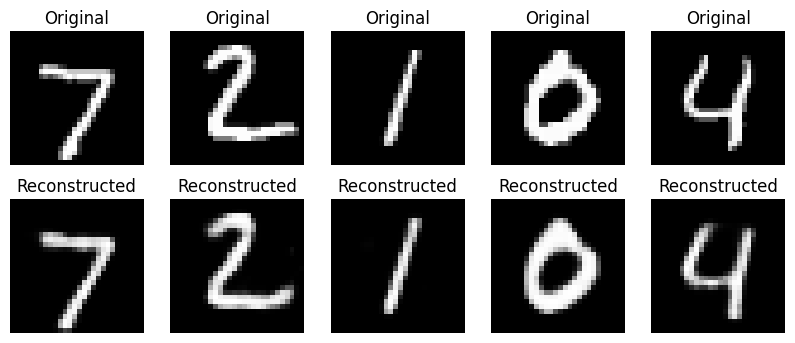

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(5):
    # Original
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    # Reconstructed
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Reconstructed")

plt.show()